'''  
강의자료를 예습하고 마크다운으로 정리해주세요!

---

1. 생성 모델
    - 분류모델과 생성모델의 차이
    - 생성모델의 분류
        - AE
        - VAE
        - GAN
            - 구조와 장단점
        - 확산모델
            - 순확산과 역확산
2. AI 최적화
    - 전이학습
        - 전이학습의 개념과 분류
        - Pre-Training과 Fine-tuning
    - AI Alignment
        - RLHF
    - 프롬프트 엔지니어링  

    '''

# **생성 모델**
## 생성 모델의 개념
### [분류 모델 vs 생성 모델]
- 생성 모델의 개념: 주어진 학습 데이터를 학습해 학습 데이터의 분포를 따르는 **유사 데이터를 샘플링하는 모델**  
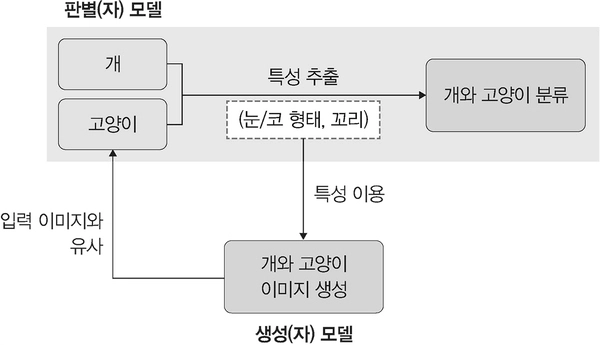
- 분류 모델 vs 생성 모델  

    | 구분 | 분류 모델 | 생성 모델 |
    | --- | --- | --- |
    | 개념 | 입력 데이터가 **어떤 레이블에 속할지** 결정하는 모델 | 주어진 학습 데이터의 확률 분포를 학습해 학습 데이터와 **유사한 새로운 데이터를 만드는** 모델 |
    | 학습 목표 | 데이터 X가 주어졌을 때 정답 Y일 확률 계산 | 세상에 존재할 법한 데이터 X 자체의 확률 분포 파악 | 
    | 특징 | 불합리한 데이터도 기존 라벨에 매칭해야함 | **불합리한 데이터는 확률을 0으로 판단 -> 거부 가능** |

### [생성 모델의 분류]
- 분류 기준: **확률 밀도를 직접 계산할 수 있는가?**
- **명시적** 확률밀도 모델: 모델이 데이터의 확률분포인 **P(X)의 값을 직접 수치화**하여 출력 가능
    - 정확히 계산 가능한 모델(Tractable): 수학적으로 정확히 계산 가능(ex: 자기회귀 모델)
    - 근사적 밀도 모델(approximate): 정확한 확률값 계산이 복잡 -> 근삿값 또는 하한선 계산(ex: VAE)
- **암시적** 확률밀도 모델: 데이터의 확률 분포 P(X)가 무엇인지 수치로 계산 불가, 그 분포를 따르는 데이터 생성은 가능
    - 직접 샘플링: 신경망을 한 번 통과시켜 데이터를 바로 생성 (ex: GAN-가짜/진짜 비교를 통해 샘플링 능력 향상)
    - 간접/반복적 샘플링: **마르코브 체인**. 이전 단계의 상태를 바탕으로 다음 단계를 예측하는 과정을 반복 -> 점진적으로 데이터 완성 (ex: GSN - 마르코프 연쇄의 전이 연산자 학습 -> 다음에 어떤 데이터를 생성할지 결정하는 규칙을 학습, 확산 모델)


## AE, VAE
### [AE - Auto Encoder]
- 개념: **입력과 동일한 출력을 만드는 것을 목적**으로 하는 신경망
- 사용 예시: **데이터 복원**이나 **특성 학습** (차원 축소, 특징 추출, 노이즈 제거, 이상 탐지 등)
- 특징: 일반적인 인코더/디코더와 달리 정답지 X. **자기 자신을 다시 그려내는 것**이 목적
- 구조 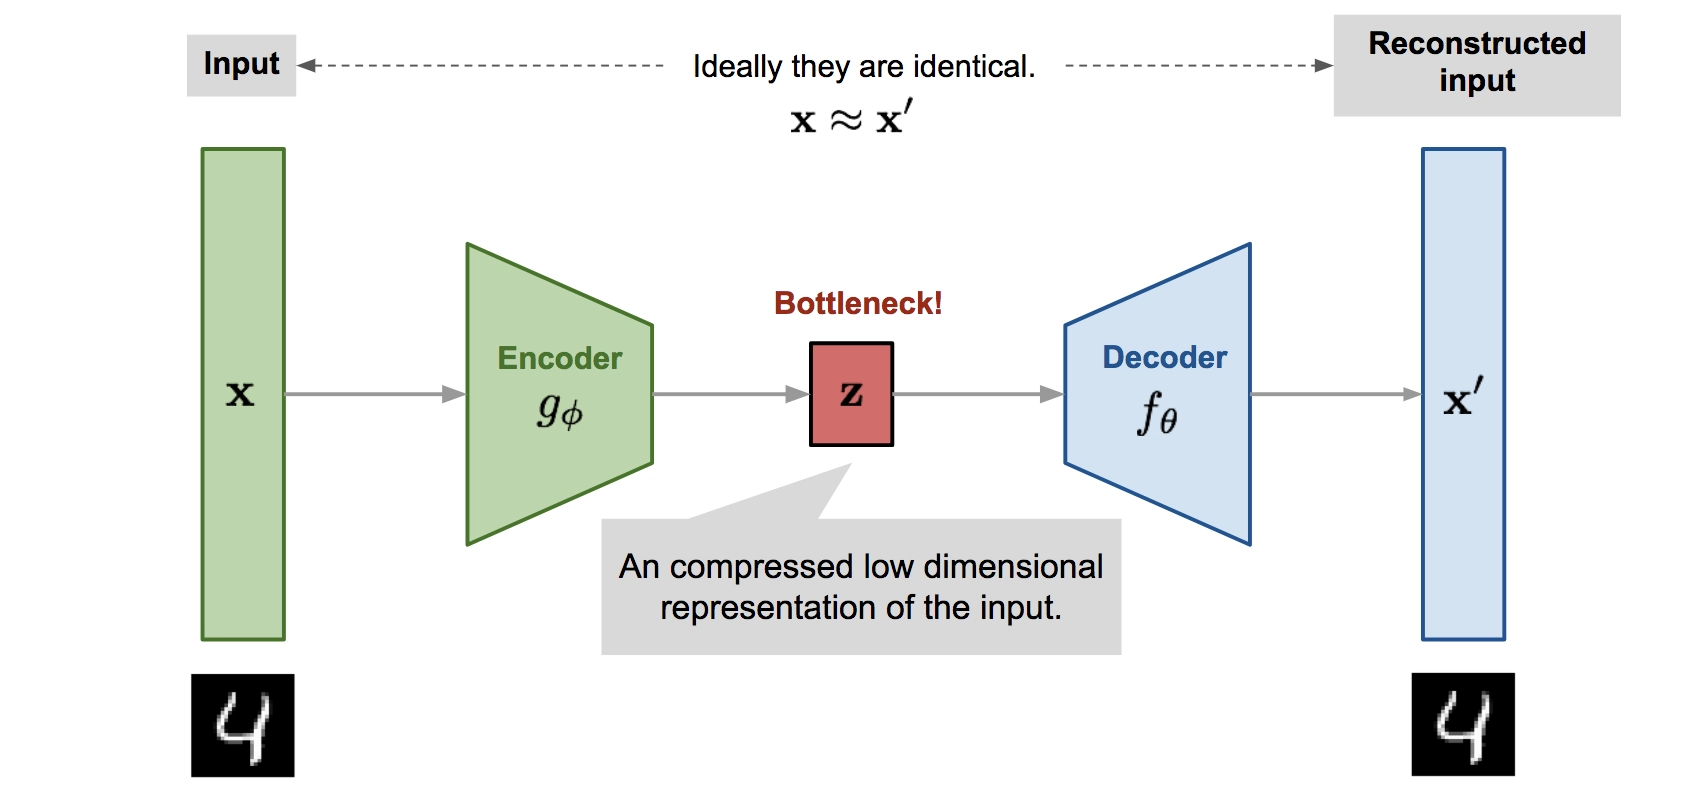
    1. **압축**: 방대한 정보를 **잠재 벡터**(Latent Vector)로 통과시키기 위해 핵심만 남김
        - **인코더**: 원래의 고차원 입력 데이터 x를 잠재표현 z로 변환하는 네트워크
        - 잠재 벡터: 입력 데이터의 중요한 정보가 압축된 벡터
    2. **병목 통과**: 가장 중요한 정보만 남은 상태. 이 좁은 구간을 잠재 벡터라고 함
        - 잠재 벡터에는 학습 과정에서 겉으로 드러나지 않는 숨겨진 특징 정보 저장
    3. **복원**: 핵심정보를 단서로 삼아, 다시 원래의 커다란 이미지로 복원
        - **디코더**: 잠재 표현 z를 풀어서 입력을 재복원 -> x' 출력
        - Latent Vector를 복원함으로써 입력 데이터가 잘 압축된 것인지 검증
    => 인코더로 들어가는 입력 데이터 x와 디코더가 출력한 데이터 x'이 같아지도록 훈련하여 그 과정에서 데이터의 핵심 특징만 남김
    
### [VAE - Variational Auto Encoder]
- 개념: **데이터의 잠재적인 구조를 학습해 원본과 닮았지만 새로운 데이터를 생성**해내는 모델
- AE의 한계: 데이터를 잠재 공간의 특정 점으로 보냄 -> 학습할 때 쓰지 않은 빈 공간의 점일 경우 디코더가 엉뚱한 결과 출력  
-> VAE: 잠재 벡터를 점이 아닌 **가우시안 분포**(범위)로 학습
- 사용 예시: 새로운 데이터 생성 (이미지 생성, 텍스트 생성, 신호 처리, 이미지 보간 등)
- AE vs VAE 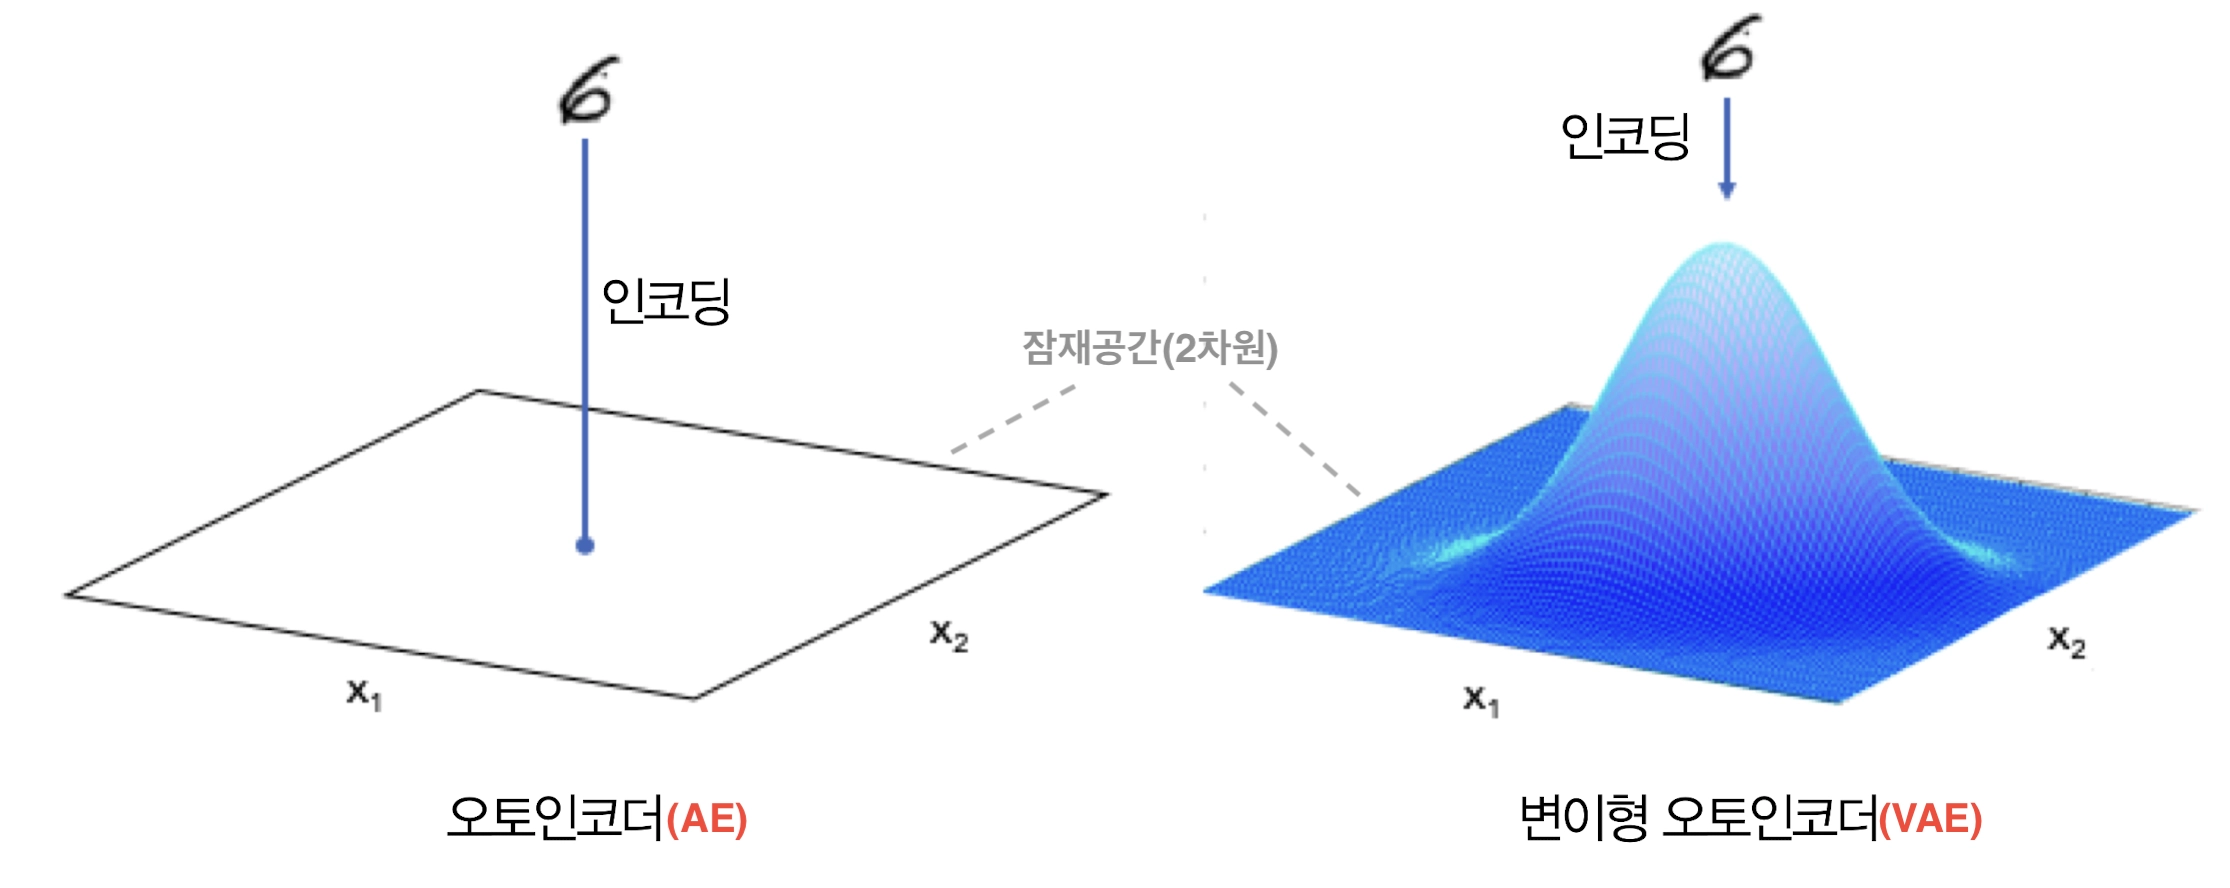

    | 구분 | AE | VAE |
    | --- | --- | --- |
    | 매핑 방법 | 입력 데이터를 하나의 고정된 수치(점)으로 매핑 | 가우시안 분포로 매핑 |
    | 특징 | 빈 공간에 매핑 시 무의미한 노이즈 출력 | 연속성(잠재 공간의 가까운 두 점이 유사한 특징 보유), 조밀함(정규 분포 주변에 모든 데이터 밀집) -> 자연스럽고 새로운 결과물 생성 |
    | 핵심 | 인코더 - 압축 | 디코더 - 셍성 | 
- 구조 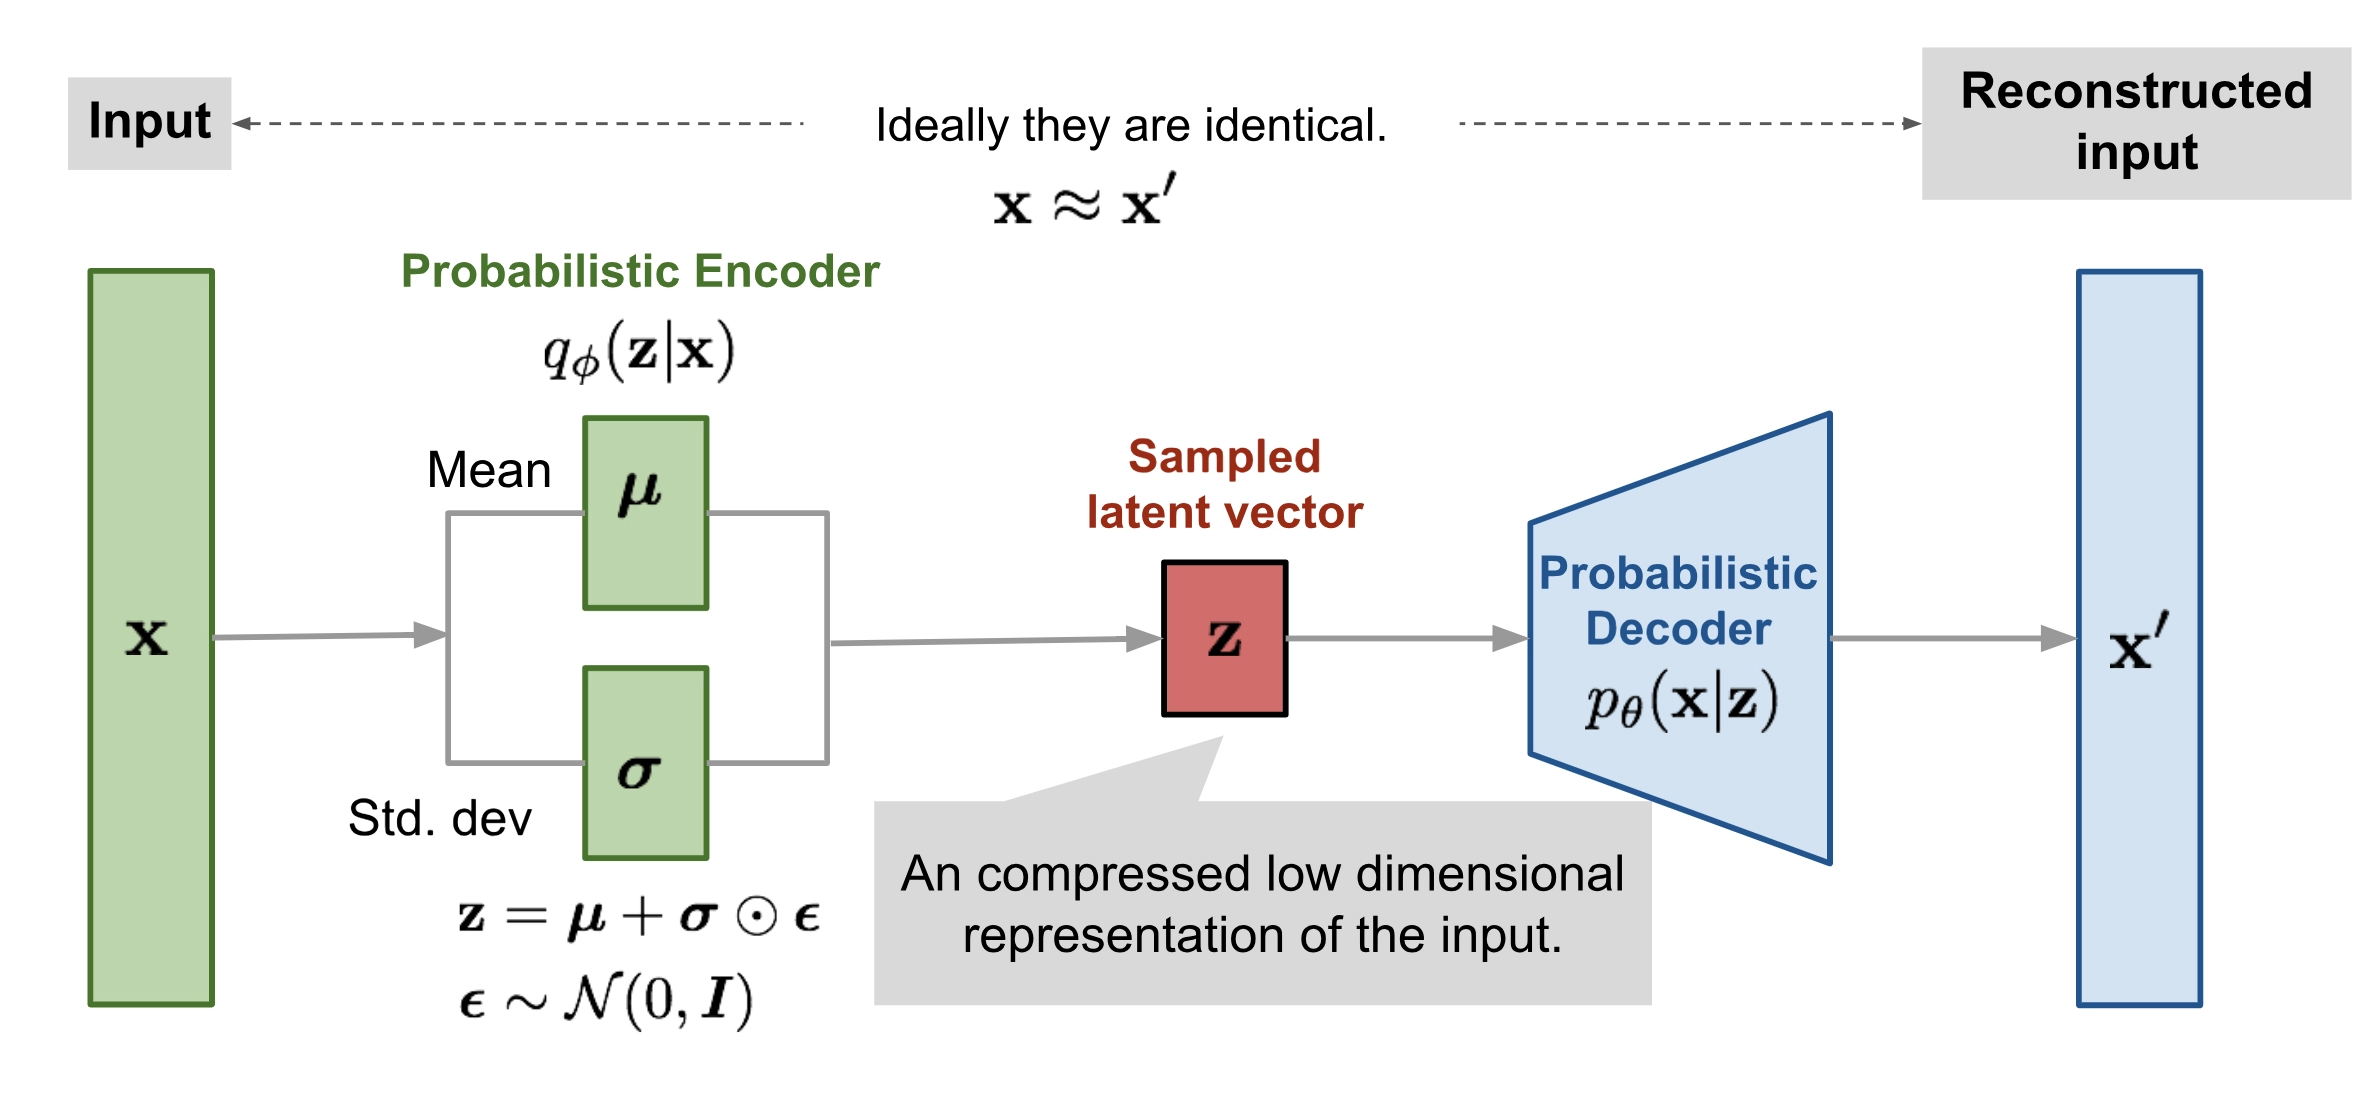
    1. **분포 예측**: 입력 데이터를 데이터가 존재할 확률이 높은 구역으로 매핑
        - **인코더**: 입력 데이터 x를 분석해 잠재 공간 상의 평균과 표준편차 계산
    2. **샘플링 및 재파라미터화**: 예측한 분포에서 실제 디코더에 전달할 잠재 벡터 z를 선택
        - 샘플링: 인코더가 찾은 범위 안에서 **무작위로** 점 하나(잠재 벡터 z) 추출  
        -> 매번 조금씩 다른 z가 만들어져 잠재 공간이 풍부하게 채워짐
    3. **생성**: 샘플링된 잠재 벡터 z를 단서로 하여 새로운 데이터 생성
        - **디코더**: 저차원의 핵심 정보 z를 다시 고차원의 데이터 x'으로 복원

## GAN - Generative Adversarial Network
### [개념]
- 생성적 적대 신경망
- 개념: **생성자** 신경망과 **판별자** 신경망이 서로 적대적으로 경쟁 -> **훈련을 통해 자신의 작업을 점점 더 정교하게 수행**하는 신경망 모델
- 목적
    - 생성자: 진짜 분포에 가까운 가짜 분포 생성
    - 판별자: 표본이 가짜/진짜 분포 중 어디에 속하는지 결정
    => 실제 데이터의 분포에 가까운 데이터를 생성하는 것이 궁극적 목표. **판별자가 진짜/가짜를  판단하지 못하는 경계를 최적 솔루션으로 간주**
- 사용 예시: 이미지 생성, 영상 합성

### [구조]
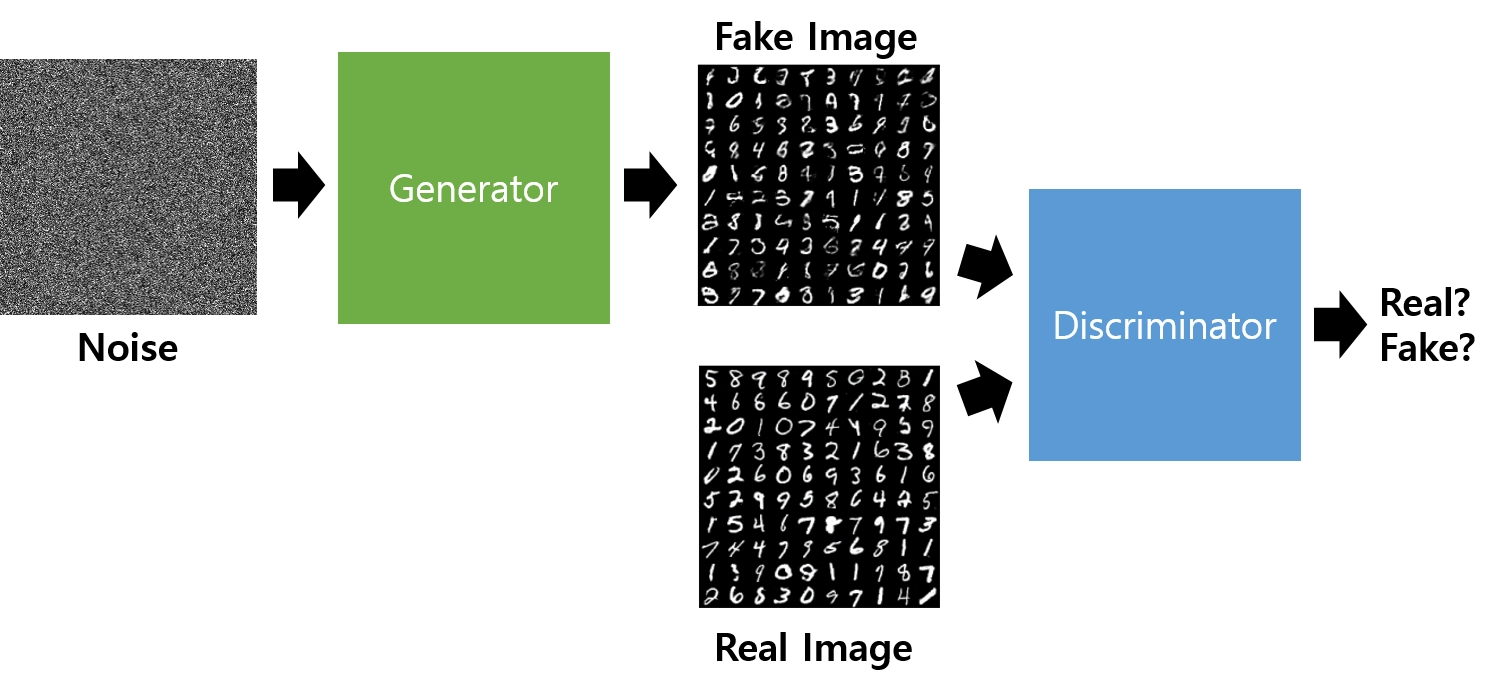  
- 생성자(Gernerator)
    - 입력: 우리가 직접 제어할 수 있는 **무작위 노이즈**(잠재 변수 Z)
    - 출력: 실제 데이터와 유사한 가짜 데이터(G(Z))
    - 목표: 판별자를 속여서 가짜를 진짜로 믿게 만드는 것
- 판별자(Discriminator)
    - 입력:  **실제 데이터**(X)와 생성자가 만든 **가짜 데이터**(G(Z))
    - 출력: 입력 데이터가 진짜일 확률
    - 목표: 진짜는 1로, 가짜는 0으로 분류하는 것

### [장단점]
- 장점: 진짜같은 가짜 생성 가능, **압도적 선명도**, **빠른 생성 속도**, 잠재 공간의 부드러움
    - VAE는 픽셀 간의 수학적 평균값(MSE 등)을 최적화하기 때문에 이미지가 흐릿해지는 경향이 있지만, GAN은 판별자를 속여야 한다는 강력한 목표 덕분에 실제 데이터와 통계적으로 유사한 미세한 질감까지 살려내므로 선명도가 높다.
- 한계점: **학습의 불안정성**(진동 현상 - 에폭이 진행될수록 손실값이 진동해서 모델이 하나의 최적점에 안착 X, 무한루프 - 생성자와 판별자의 업데이트 계속), 훈련 초기 **그래디언트 소멸** 문제, **모드 붕괴**(특정 패턴만 계속 생성. 다양성 X), 지표 부재, 역매핑 불가(특징 추출 X)

## 확산 모델
### [개념]
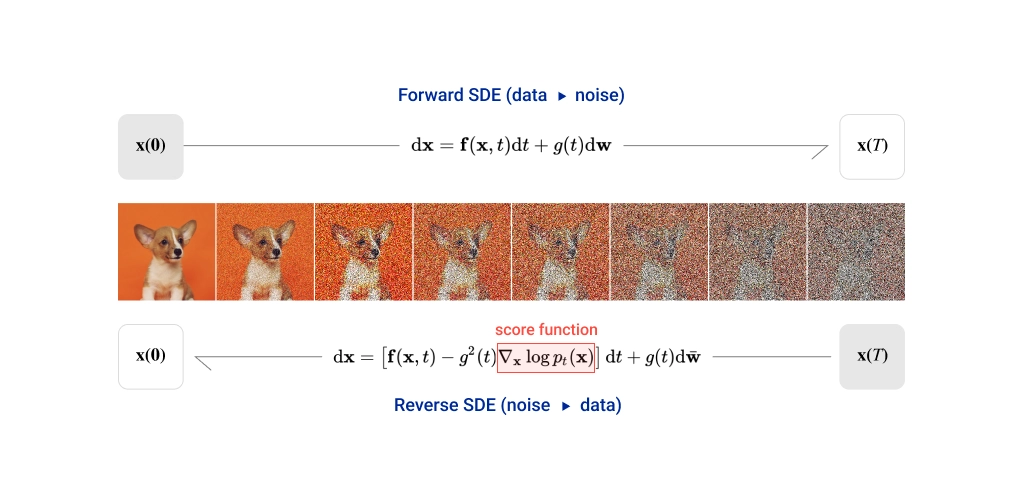
- **입력 이미지**에 노이즈를 조금씩 추가하여 **완전한 노이즈**로 만든 뒤, 이를 다시 거꾸로 **복원**하는 과정을 학습하여 입력 이미지와 유사한 확률 분포를 가진 **결과 이미지를 생성**하는 모델
- 목적: 순확산과 역확산 단계를 거쳐 생성된 '결과 이미지'의 확률 분포를 '원래 데이터'의 확률 분포와 최대한 유사하게 만드는 것

### [구조]
- 순확산: 데이터에 점진적으로 노이즈를 추가하는 과정 -> 원래 데이터를 점차적으로 무작위 노이즈로 변형 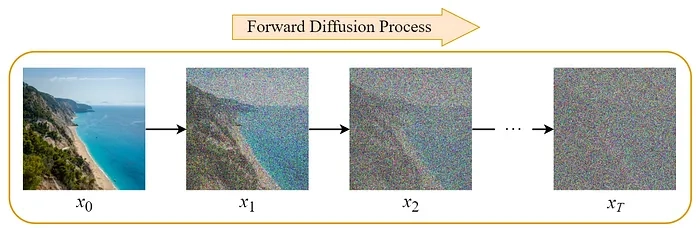
    1. 원본 데이터에서 시작
    2. 점진적으로 노이즈 추가
    3. 충분히 많은 단계를 거쳐 **완전한 무작위 노이즈**로 변환
- 역확산: 노이즈 데이터에서 원본 데이터를 재구성하는 과정 -> 순확산 과정에서 추가된 노이즈를 제거하여 원래의 데이터를 복원 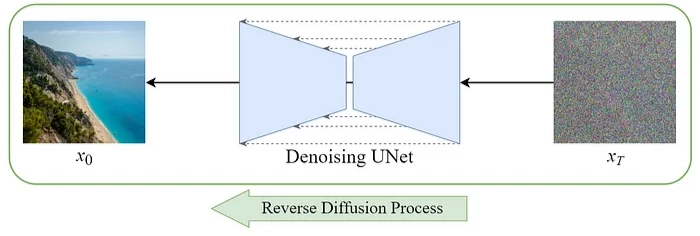
    1. 완전한 노이즈 데이터에서 시작
    2. 단계별로 추가된 노이즈 예측, 제거
    3. 점진적으로 이미지 복원

### [장단점]
- 장점: **압도적인 샘플링 품질**(GAN보다 정교, 다양한 이미지), 학습 안정성, 다양성 확보(GAN의 모드 붕괴 현상 거의 X)
- 단점: **느린 생성 속도**, 높은 계산 비용, 구조적 제약

# **AI 최적화**
## 전이학습
### [개념]
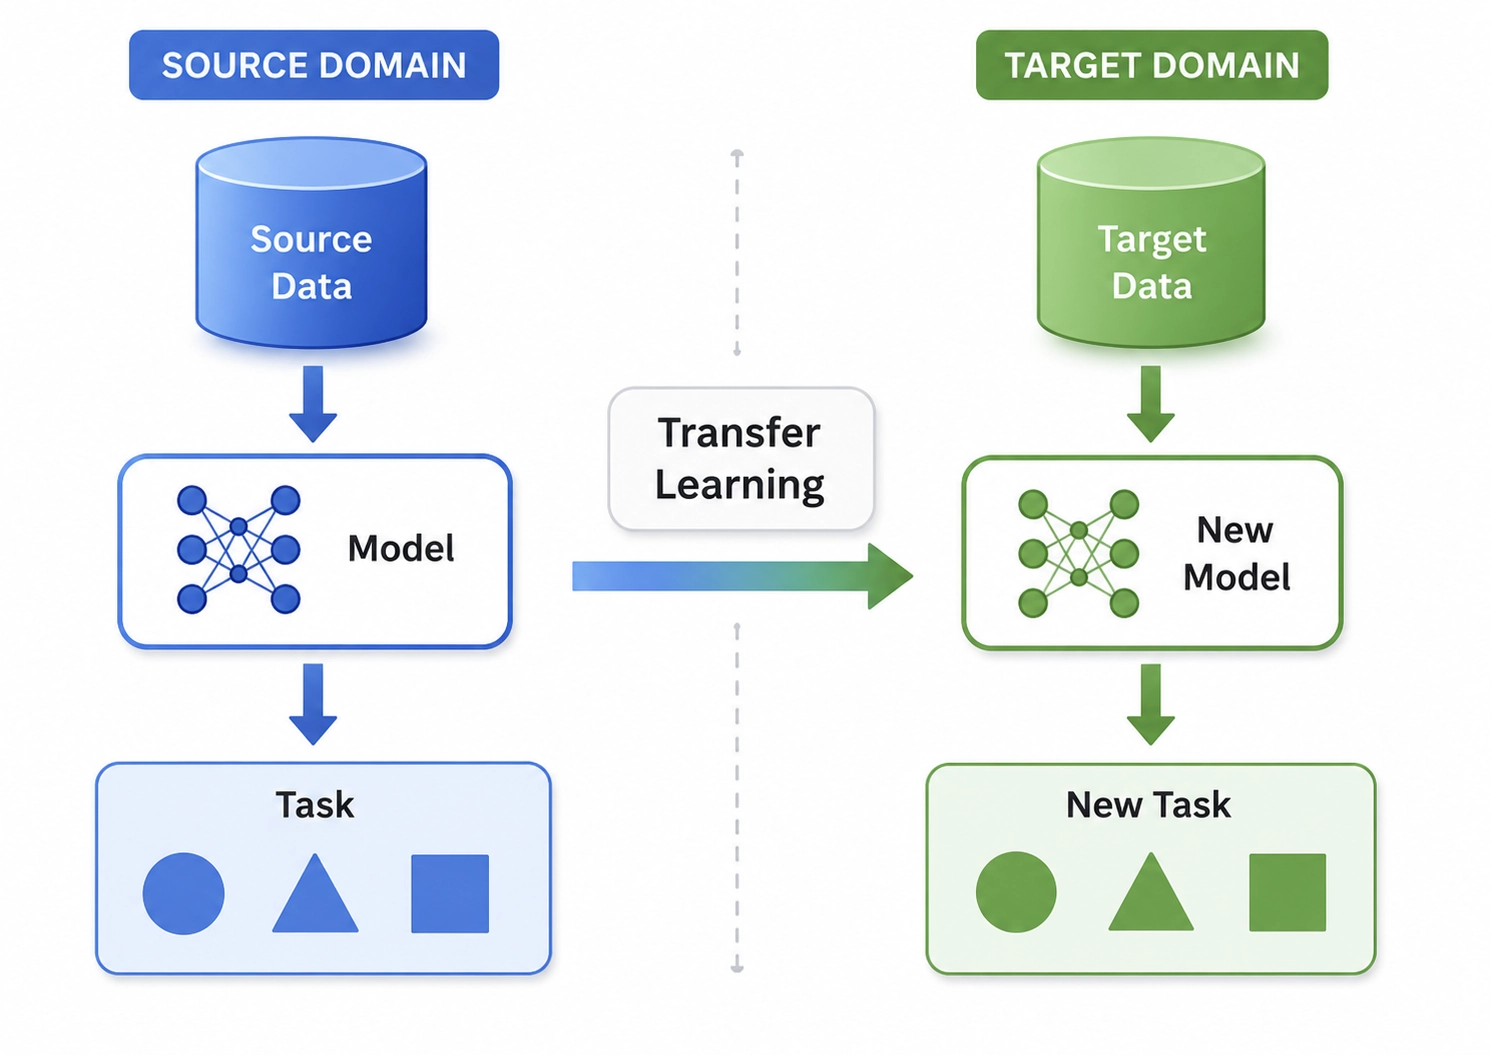  
- domain: 어떤 데이터를 다루고 있는가?
- task: 그 데이터로 무엇을 예측하는가?
- source: 전이학습의 출발점 -> 어디서 지식을 가져오는가?(= 이미 학습이 완료된 모델이 있는 곳)
    - source domain: 그 모델이 학습한 데이터
    - source task: 그 모델이 학습한 태스크
- target: 전이학습의 도착점 -> 어디에 지식을 적용하는가?(= 내가 실제로 풀고싶은 문제)
    - target domain: 내가 가진 데이터
    - target task: 내가 하고싶은 태스크
=> 전이학습: **출발점/도착점의 데이터 또는 과제가 다를 때**, 출발점에서 배운 걸 가져다가 도착점 문제를 더 잘 풀게 만드는 것 -> 데이터나 문제 유형이 달라도 **다른 상황에서 배운 지식을 가져와서 새로운 상황에서 성능 향상**

### [분류]
#### 도메인과 태스크의 상태에 따른 분류
- 귀납적 전이학습: 소스와 타겟의 task가 다르고 타겟 도메인에 라벨이 존재할 때
- 트랜스듀서형 전이학습: 소스와 타겟의 task는 같지만 도메인이 다를 때
- 비지도 전이학습: 소스와 타겟의 task가 다르고 소스와 타겟 모두 라벨이 없을 때
#### 무엇을 전이하느냐에 따른 분류
- 인스턴스: 데이터 레벨의 전이 -> 소스 데이터 중 타겟에 도움이 될만한 샘플을 골라 가중치를 부여
- 특징: 표현 레벨의 전이 -> 소스와 타겟의 공통적인 특징을 추출할 수 있는 표현 방식 전이
- 파라미터: 모델의 가중치나 하이퍼파라미터 초기값을 그대로 전달
- 관계: 데이터 간의 논리적 관계나 구조적 지식 전이

### [Pre-training과 Fine-tuning]
- 트랜스포머 등장 이전: 각 업무에 맞는 모델을 처음부터 만듦. 사전학습된 좋은 모델 X -> **어떻게 지식을 옮길지** 고민
- 트랜스포머 등장 이후: 엄청난 양의 데이터로 **사전학습된 거대 모델(Pre-trained Model)** 등장 -> **이미 잘 학습된 거대 모델을 용도에 맞게 어떻게 조정할지(Fine-tuning)** 고민
- 파운데이션 모델: 방대한 양의 비정형, 레이블이 없는 데이터로 비지도 학습을 통해 훈련된 거대한 AI 모델
- fine tuning의 한계: 파라미터가 수십억개인 모델을 파인튜닝하려면 비용 부담이 큼  
    -> **PEFT(Parameter-Efficient Fine-Tuning)**: 원래 모델의 파라미터는 고정하고 별도의 작은 파라미터만 추가적으로 학습

### [전이학습의 한계]
- **Negative Transfer**: Source와 Target의 도메인이 너무 다르면 오히려 전이가 성능을 떨어뜨리는 현상 -> Maximum Mean Discrepancy(MMD)
- **Catastrophic Forgetting**: Fine-tuning 과정에서 새 데이터에 너무 치우치면, 모델이 원래 가지고 있던 일반 능력을 잃어버리는 현상 -> Elastic Weight Consolidation(EWC)
- **Bias Transfer**: 사전 학습 데이터에 담긴 편향이 그대로 넘어오는 현상
- **Transferability 측정 어려움**: 어떤 두 Task가 얼마나 관련되어 있는지를 사전에 정량적으로 측정하기 어려움 -> LEEP, LogME

### [전이학습 사용사례]
- 컴퓨터 비전: 의료 영상 분석, 자율주행
- 자연어 처리: 법률 문서 분석, 기업 특화 챗봇
- 의료, 신약 계발: 단백질 구조 예측
- 제조, 산업: 공장 불량 검출

### [딥러닝 경량화]
- 가지치기: 모델의 파라미터 중 중요도가 낮은 가중치를 제거 -> 모델의 크기를 줄이고, 연산 속도를 높이는 기법
- 양자화: 모델의 가중치를 표현하는 숫자의 정밀도를 줄이는 방법
- 지식 증류: 크고 똑똑한 모델(Teacher)의 지식을 작은 모델(Student)에게 가르쳐 주는 방법
- 모델 구조 경량화: 처음부터 가볍게 설계된 모델 사용
- 하드웨어 가속화: 소프트웨어적으로 모델을 줄이는 게 아니라, AI 연산에 특화된 하드웨어를 쓰는 방법

## AI Alignment
- 개념: AI가 인간의 의도, 목표, 윤리적 가치에 부합하도록 행동하게 만드는 연구 분야
- 정렬의 기준: **Helpful**(도움이 되는가) / **Honest**(정직한가) / **Harmless**(무해한가)
- **outer alignment**: 목표를 제대로 설정했는가?
    -  모델이 보상을 극대화하기 위해 인간의 의도와는 무관한 꼼수를 부리는 현상을 해결하기 위함 -> **RLHF**
- **inner alignment**: 모델이 내면에서 무엇을 최적화하는가?
    - 모델이 훈련 중에는 인간의 감시를 피하기 위해 정렬된 척 행동하다가, 실제 배포된 후(감시가 없을 때)에는 자신의 원래 목표를 수행하는 '기만적 행동(Deceptive Alignment)'을 할 가능성 존재
    - 모델의 실제 내부 동작을 해석 가능하게 만드는 것
- 정렬을 어렵게 만드는 요인들
    - 가치 정렬의 모호성: 사람마다 중요시하는 가치 다름 -> 어떤 인간의 가치에 맞출 것인가?
    - 확장 가능한 감독: AI가 더 똑똑해서 인간이 이해하지 못하는 답변에 대해 어떻게 피드백을 줄 것인가? 

### [RLHF]
- 모델이 문장은 잘 생성하지만, 사람이 원하는 답을 이해하지는 못해 원하는 답변을 제공하지 못하는 Outer Alignment 문제를 해결
- 인간의 피드백을 바탕으로 모델을 **강화학습**을 통해 조정 -> **답변에 대한 선호도** 학습
- 단계
    1. **지도 미세 조정** (Supervised Fine-Tuning, SFT): 사전 학습된 모델이 **인간의 지시를 따르는 방법을 배우는 과정**
        - 데이터 구축: 사람이 직접 작성한 프름프트-답변 쌍 수집
        - 학습 방식: 지도학습 (사람이 작성한 모범 답안 학습)
    2. **보상 모델 학습** (Reward Model, RM): 모델이 생성한 답변이 얼마나 좋은지 인**간의 선호도에 따라 점수를 매기는 '채점기'를 만드는 단계**
        - 데이터 구축: 동일한 질문에 대한 여러 답변을 사람이 평가
        - 학습 방식: 비교학습(두 답변 중 선호도가 높은 답변에 더 높은 점수 부여)
    3. **강화 학습** (Reinforcement Learning, RL): 보상 모델을 기준으로 언어 모델의 성능을 극대화
        - 점수를 높이는 방향으로 모델 파라미터 업데이트
        - KL 발산 제약: 학습 과정에서 모델이 보상 점수만 따지다가 너무 이상한 문장을 만들거나 원래의 지식을 잊어버리지 않도록 규제항을 추가

## 프롬프트 엔지니어링
- 모델은 그대로 두고 입력만 잘 설계해서 원하는 답을 끌어내는 것
- 배포 속도가 빠르고 비용이 적게 든다.
- 주요 기법
    - Zero-shot: 예시 없이 바로 질문
    - Few-shot: 예시를 몇 개 보여주고 질문 -> zero-shot보다 정확
    - Chain-of-Thought(CoT): AI가 **풀이과정을 단계별로 생각**하게 만들어서 복잡한 수학 문제나 논리추론에서 정확도를 높이는 것
    - Role Prompting: AI한테 **특정 역할을 맡겨서** 그 역할에 맞는 답변을 끌어내는 기법
    - Instruction Prompting: AI한테 원하는 걸 **최대한 구체적으로 지시**하는 기법
    - Self-Consistency: **같은 질문을 여러 번 해서 가장 많이 나온 답을 채택**하는 기법
    - RAG (Retrieval-Augmented Generation): AI가 모르는 최신 정보나 특정 도메인 지식을 **외부 데이터베이스에서 검색해서 프롬프트에 함께 제공**하는 방식
- 한계
    - Prompt Injection: 악의적인 사용자가 프롬프트를 조작해서 AI를 엉뚱하게 동작시키는 보안 문제
    - Hallucination: AI가 없는 정보를 그럴듯하게 지어내는 현상
    - 모델 의존성: 모델마다 프롬프트에 다르게 반응
    - 성능 한계: Fine-tuning 대비 낮은 성능
